In [1]:
import os
import glob
import numpy as np
import mdtraj as md
import scipy.linalg
import matplotlib.pyplot as plt
import deeptime.markov as markov
from deeptime.clustering import KMeans
from deeptime.util.validation import implied_timescales
from deeptime.plots import plot_implied_timescales, plot_energy2d
from deeptime.util import energy2d
from deeptime.markov import TransitionCountEstimator



In [ ]:
def get_features(traj_path, top_path, pairs=None):
    t = md.load(traj_path, top=top_path)
    t = t[1:] # Skip shifted frame 0
    ca_indices = t.topology.select("name CA")
    if pairs is None:
        pairs = t.topology.select_pairs(ca_indices, ca_indices)
    r = md.compute_distances(t, pairs)
    return 1.0 / (1.0 + (r / 0.90)**6), pairs


class RobustSFA:
    def __init__(self, n_components=2, reg=1e-8):
        self.n_components = n_components
        self.reg = reg
        self.mean = None
        self.vectors = None

    def fit(self, trajectories):
        """
        trajectories: list of arrays, each (T_i, n_features), time-ordered.
        """
        X = np.vstack(trajectories)
        self.mean = X.mean(axis=0)
        Xc = X - self.mean

        C = np.cov(Xc, rowvar=False)
        C += np.eye(C.shape[0]) * self.reg

        dX_list = []
        for Xi in trajectories:
            Xic = Xi - self.mean
            dX_list.append(Xic[1:] - Xic[:-1])
        dX = np.vstack(dX_list)

        H = np.cov(dX, rowvar=False)

        evals, evecs = scipy.linalg.eigh(H, C)
        idx = np.argsort(evals)
        self.vectors = evecs[:, idx[:self.n_components]]
        return self

    def transform(self, data):
        return (data - self.mean) @ self.vectors


In [ ]:

md_root = "/home/tomgolf/GITHUB/MyProjects/Diploma_Thesis/06_bioemu/musM_OBP5/MDs/md_results"

md_feature_trajs = []
pairs_ref = None
clusters_to_skip = []

for i in range(20):
    if i in clusters_to_skip:
        print(f"Skipping cluster {i}")
        continue
    folder = os.path.join(md_root, f"cluster_center_{i:03d}")
    traj = os.path.join(folder, "trajectory.dcd")
    top  = os.path.join(folder, "equilibrated.pdb")
    if not os.path.exists(traj):
        print(f"Trajectory not found for cluster {i}")
        continue

    feats, pairs_ref = get_features(traj, top, pairs=pairs_ref)

    md_feature_trajs.append(feats)



dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and

In [ ]:

sfa_model = RobustSFA(n_components=2).fit(md_feature_trajs)
md_projections = [sfa_model.transform(X) for X in md_feature_trajs]

In [ ]:


all_data = np.concatenate(md_projections)
clustering = KMeans(n_clusters=10).fit(all_data).fetch_model()
dtrajs = [clustering.transform(p) for p in md_projections]

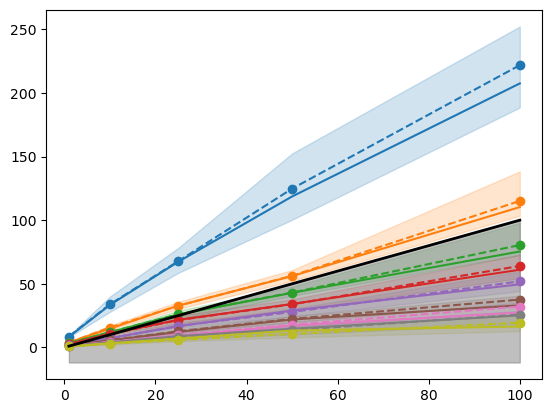

AttributeError: module 'matplotlib.pyplot' has no attribute 'save'

In [ ]:
lagtimes = [1, 10, 25, 50, 100]
its_models = []
for lt in lagtimes:
    counts = markov.TransitionCountEstimator(lagtime=lt, count_mode='effective').fit_fetch(dtrajs)
    its_models.append(markov.msm.BayesianMSM(n_samples=10).fit_fetch(counts))

plot_implied_timescales(implied_timescales(its_models))
plt.show()

plt.savefig("implied.pdf")
plt.show()



Macrostate Populations: [0.07341144 0.92658856]


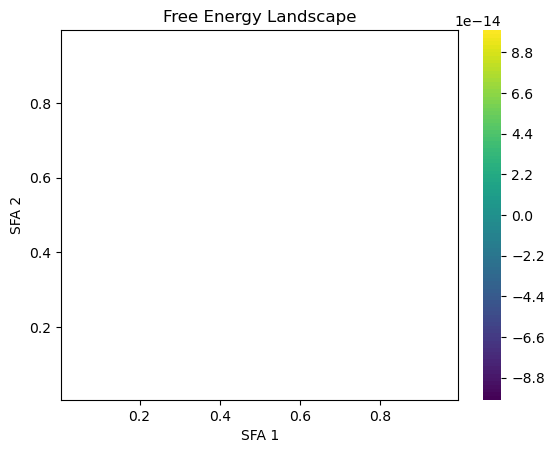

In [ ]:
final_lag = 20
counts = markov.TransitionCountEstimator(lagtime=final_lag, count_mode='effective').fit_fetch(dtrajs)

msm = markov.msm.MaximumLikelihoodMSM().fit_fetch(counts)

pcca = msm.pcca(2)
macro_pops = msm.stationary_distribution @ pcca.memberships
print(f"Macrostate Populations: {macro_pops}")

n_states = int(max(dt.max() for dt in dtrajs)) + 1
mapping = -np.ones(n_states, dtype=int)

all_data_lcs = []
all_weights = []

for proj, dt in zip(md_projections, dtrajs):
    mapped = mapping[dt]
    keep_mask = mapped >= 0

    dt_kept = mapped[keep_mask]
    proj_kept = proj[keep_mask]

    if len(dt_kept) < 2:
        continue

    w = msm.compute_trajectory_weights([dt_kept])[0]

    all_data_lcs.append(proj_kept)
    all_weights.append(w)


fel = energy2d(all_data_lcs, all_data_lcs, weights=all_weights)
plot_energy2d(fel)
plt.xlabel("SFA 1")
plt.ylabel("SFA 2")
plt.title("Free Energy Landscape")
plt.show()


In [ ]:
total_frames = sum(len(dt) for dt in dtrajs)
kept_frames  = sum(np.sum(mapping[dt] >= 0) for dt in dtrajs)
print("Frames kept in LCS:", kept_frames, "/", total_frames, "=", kept_frames/total_frames)


Frames kept in LCS: 0 / 14985 = 0.0


In [ ]:
fel_unw = energy2d(all_data_lcs[:,0], all_data_lcs[:,1])
plot_energy2d(fel_unw)
plt.title("Unweighted density in SFA space")
plt.show()


TypeError: list indices must be integers or slices, not tuple

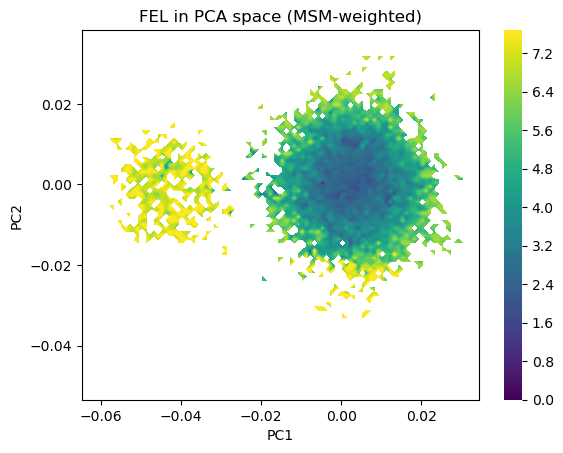

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
xy = pca.fit_transform(all_data_lcs)  # or original features

fel_pca = energy2d(xy[:,0], xy[:,1], weights=all_weights)
plot_energy2d(fel_pca)
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.title("FEL in PCA space (MSM-weighted)")
plt.show()
